In [1]:
# Colab compatibility: install packages not preinstalled there (no-op locally / on Colab reruns)
import importlib.util, subprocess, sys
for pkg, mod in [('faiss-cpu', 'faiss'), ('lightgbm', 'lightgbm')]:
    if importlib.util.find_spec(mod) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

# 05 - Ranking: Feature Engineering + LightGBM (LambdaRank)

The second stage of the funnel. Retrieval (two-tower + FAISS) narrows 100K+ items to 100 candidates using a single dot product; the **ranker** can afford to be expensive per candidate - it sees rich features the towers can't use and re-orders the top-100 into the final top-10.

## Why a GBDT and not another neural net?

On *tabular features* (counts, ratios, recencies), gradient-boosted trees remain the strongest and cheapest option - they handle mixed scales, missing values and feature interactions natively, with millisecond inference. **LambdaRank** is the listwise objective: instead of predicting a score's value (regression) or a click probability (classification), each boosting step reweights pairs by **|ΔNDCG|** - how much swapping the pair would change NDCG - so the model optimizes exactly the metric we report.

## Anti-leakage layout (defense-critical)

| Data period | Used for |
|---|---|
| train | feature computation + retrieval history |
| val | ranker **labels** (did the user like the candidate?) |
| test | final evaluation only - never seen by any training step |

Every feature is computed from the train period only. A feature computed on val/test would leak the answer into the input - the classic ranking bug.

## 0. Setup - load data + two-tower artifacts from notebook 04

In [2]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['OMP_NUM_THREADS'] = '1'   # macOS: torch/faiss/lightgbm each bundle OpenMP; single-thread everything   # macOS: torch and faiss each bundle OpenMP; without this the kernel segfaults on import faiss

import json, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import faiss
import lightgbm as lgb

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
rng = np.random.default_rng(SEED)
device = torch.device('cuda' if torch.cuda.is_available()
                      else 'mps' if torch.backends.mps.is_available() else 'cpu')

# SMOKE MODE: small user samples + fewer boosting rounds - validates the whole
# pipeline (features -> LambdaRank -> ablation -> artifact export) in minutes.
# Never report SMOKE numbers; rerun with SMOKE = False after real 04 artifacts exist.
SMOKE = False

try:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_DIR = '/content/drive/MyDrive/recsys_kindle/data'
except ImportError:
    DATA_DIR = './data'
ART_TT = os.path.join(DATA_DIR, 'artifacts_two_tower')

train = pd.read_parquet(os.path.join(DATA_DIR, 'train.parquet'))
val   = pd.read_parquet(os.path.join(DATA_DIR, 'val.parquet'))
test  = pd.read_parquet(os.path.join(DATA_DIR, 'test.parquet'))
with open(os.path.join(DATA_DIR, 'id_mappings.json')) as f:
    mappings = json.load(f)
N_USERS, N_ITEMS = len(mappings['user2idx']), len(mappings['item2idx'])

with open(os.path.join(ART_TT, 'config.json')) as f:
    cfg = json.load(f)
DIM, HIDDEN, MAX_HIST, PAD = cfg['dim'], cfg['hidden'], cfg['max_hist'], cfg['pad']
GAMMA = cfg.get('gamma', 1.0)   # 1.0 = plain mean pooling (v1 artifacts)

class TwoTower(nn.Module):
    """Must match notebook 04 exactly (state dict keys)."""
    def __init__(self, n_items, dim, hidden, gamma=1.0):
        super().__init__()
        self.emb = nn.Embedding(n_items + 1, dim, padding_idx=n_items)
        self.user_mlp = nn.Sequential(nn.Linear(dim, hidden), nn.ReLU(), nn.Linear(hidden, dim))
        self.item_mlp = nn.Sequential(nn.Linear(dim, hidden), nn.ReLU(), nn.Linear(hidden, dim))
        self.gamma = gamma
    def user_tower(self, hist, mask):
        # must match notebook 04 exactly (recency-weighted pooling; gamma=1.0 -> plain mean)
        pos  = mask.cumsum(1)
        n    = mask.sum(1, keepdim=True)
        dist = (n - pos).clamp(min=0)
        w    = (self.gamma ** dist) * mask
        w    = w / w.sum(1, keepdim=True).clamp(min=1e-8)
        pooled = (self.emb(hist) * w.unsqueeze(-1)).sum(1)
        return F.normalize(self.user_mlp(pooled), dim=-1)

tower = TwoTower(N_ITEMS, DIM, HIDDEN, gamma=GAMMA).to(device)
tower.load_state_dict(torch.load(os.path.join(ART_TT, 'two_tower.pt'), map_location=device))
tower.eval()

item_emb = np.load(os.path.join(ART_TT, 'item_embeddings.npy'))
index = faiss.read_index(os.path.join(ART_TT, 'faiss.index'))
print(f'Loaded two-tower ({DIM}d) + FAISS index with {index.ntotal:,} items')
faiss.omp_set_num_threads(1)

Loaded two-tower (128d) + FAISS index with 120,573 items


## 1. Feature engineering - 12 features, 4 families

All computed from **train only**, with the reference time = end of the train period (what the model "knows" at serving time).

| # | Feature | Family | Intuition |
|---|---------|--------|-----------|
| 1 | `u_n_interactions` | user | overall activity - heavy readers behave differently |
| 2 | `u_avg_rating` | user | rating strictness (a 4★ from a harsh rater ≠ from a generous one) |
| 3 | `u_days_since_last` | user/temporal | account dormancy at reference time |
| 4 | `u_n_recent_30d` | user/temporal | current engagement burst |
| 5 | `i_popularity` | item | positive-interaction count - the strong prior |
| 6 | `i_avg_rating` | item | quality signal, complements raw popularity |
| 7 | `i_days_since_first` | item/temporal | catalog age - new books behave differently |
| 8 | `i_n_recent_30d` | item/temporal | trending-now signal |
| 9 | `x_retrieval_score` | cross | two-tower cosine - the retriever's opinion |
| 10 | `x_retrieval_rank` | cross | position in the candidate list (0 = best) |
| 11 | `x_max_sim_last5` | cross | max cosine of candidate to user's 5 most recent likes - "close to what you just read" |
| 12 | `x_cat_match` | cross | candidate's category appears in user's history categories |

In [3]:
T_REF = train.timestamp.max()
DAY_MS = 86_400_000

# --- user-level (train only) ---
g = train.groupby('user_idx')
user_feat = pd.DataFrame({
    'u_n_interactions': g.size(),
    'u_avg_rating':     g.rating.mean(),
    'u_days_since_last': (T_REF - g.timestamp.max()) / DAY_MS,
    'u_n_recent_30d':   train[train.timestamp > T_REF - 30 * DAY_MS].groupby('user_idx').size(),
}).fillna({'u_n_recent_30d': 0})

# --- item-level (train only) ---
gi = train.groupby('item_idx')
item_feat = pd.DataFrame({
    'i_popularity':       train[train.is_positive].groupby('item_idx').size(),
    'i_avg_rating':       gi.rating.mean(),
    'i_days_since_first': (T_REF - gi.timestamp.min()) / DAY_MS,
    'i_n_recent_30d':     train[train.timestamp > T_REF - 30 * DAY_MS].groupby('item_idx').size(),
}).reindex(range(N_ITEMS)).fillna({'i_popularity': 0, 'i_n_recent_30d': 0})

# --- category lookup (from items.parquet, built by app/scripts/build_items.py) ---
items_meta_path = os.path.join(DATA_DIR, 'items.parquet')
if os.path.exists(items_meta_path):
    im = pd.read_parquet(items_meta_path)
    item_cat = im.set_index('item_idx')['category'].to_dict()
else:
    item_cat = {}
    print('WARNING: items.parquet not found -> x_cat_match will be 0 everywhere')

FEATURES = ['u_n_interactions', 'u_avg_rating', 'u_days_since_last', 'u_n_recent_30d',
            'i_popularity', 'i_avg_rating', 'i_days_since_first', 'i_n_recent_30d',
            'x_retrieval_score', 'x_retrieval_rank', 'x_max_sim_last5', 'x_cat_match']
print(f'{len(FEATURES)} features | user table {user_feat.shape} | item table {item_feat.shape}')

12 features | user table (127585, 4) | item table (120573, 4)


## 2. Candidate generation for ranker training

For each user with ≥1 positive in the **val** period: retrieve top-100 with the two-tower (history = train sequence), label each candidate 1 if the user liked it in val, else 0. Groups with zero positives are dropped - LambdaRank learns from *reordering within a group*; an all-negative group has no pairs to reorder and contributes nothing.

In [4]:
pos_sorted = train[train.is_positive].sort_values(['user_idx', 'timestamp'])
user_seqs = {int(u): g.item_idx.to_numpy(dtype=np.int64) for u, g in pos_sorted.groupby('user_idx')}
seen_train = train.groupby('user_idx')['item_idx'].agg(set).to_dict()

def build_truth(part):
    p = part[part.is_positive & part.user_idx.notna() & part.item_idx.notna()]
    return p.groupby('user_idx')['item_idx'].agg(set).to_dict()

truth_val, truth_test = build_truth(val), build_truth(test)

USER_SAMPLE = 5_000 if SMOKE else 100_000   # ranker training users; more groups = better LambdaRank (document your choice)
K_CAND = 100

cand_users = [u for u in truth_val if u in user_seqs]
if len(cand_users) > USER_SAMPLE:
    cand_users = list(rng.choice(cand_users, size=USER_SAMPLE, replace=False))
print(f'{len(cand_users):,} candidate-generation users (val positives + train history)')

44,940 candidate-generation users (val positives + train history)


In [5]:
@torch.no_grad()
def embed_users(users):
    hist = np.full((len(users), MAX_HIST), PAD, dtype=np.int64)
    for r, u in enumerate(users):
        seq = user_seqs.get(u, np.array([], dtype=np.int64))[-MAX_HIST:]
        hist[r, :len(seq)] = seq
    h = torch.as_tensor(hist, device=device)
    return tower.user_tower(h, (h != PAD).float()).cpu().numpy().astype('float32')

def retrieve_batch(users, k=K_CAND, batch=8192):
    """-> {user: (item_idx array, score array)} with train-seen items filtered."""
    out = {}
    for s in range(0, len(users), batch):
        chunk = users[s:s+batch]
        buf = max((len(seen_train.get(u, ())) for u in chunk), default=0) + 10
        D, I = index.search(embed_users(chunk), k + buf)
        for u, drow, irow in zip(chunk, D, I):
            seen = seen_train.get(u, set())
            keep = [(i, d) for i, d in zip(irow, drow) if i not in seen][:k]
            out[u] = (np.array([x[0] for x in keep]), np.array([x[1] for x in keep], dtype='float32'))
    return out

t0 = time.time()
cands = retrieve_batch(cand_users)
print(f'Retrieved top-{K_CAND} for {len(cands):,} users in {time.time()-t0:.0f}s')

Retrieved top-100 for 44,940 users in 21s


## 3. Assemble the training matrix

In [6]:
faiss.omp_set_num_threads(1)
def user_hist_categories(u):
    return {item_cat.get(int(i)) for i in user_seqs.get(u, [])[-20:]} - {None}

def build_matrix(cand_dict, truth):
    """-> X (DataFrame), y, groups (list of group sizes, LightGBM format)"""
    rows, y, groups = [], [], []
    for u, (items, scores) in cand_dict.items():
        rel = truth.get(u, set())
        labels = np.fromiter((int(i) in rel for i in items), dtype=np.int8, count=len(items))
        if truth is truth_val and labels.sum() == 0:
            continue   # drop all-negative groups for TRAINING only (keep for evaluation)
        uf = user_feat.loc[u] if u in user_feat.index else pd.Series(0.0, index=user_feat.columns)
        last5 = user_seqs.get(u, np.array([], dtype=np.int64))[-5:]
        max_sim = (item_emb[items] @ item_emb[last5].T).max(axis=1) if len(last5) else np.zeros(len(items))
        ucats = user_hist_categories(u)
        for r, (i, sc) in enumerate(zip(items, scores)):
            it = item_feat.iloc[int(i)]
            rows.append((uf.u_n_interactions, uf.u_avg_rating, uf.u_days_since_last, uf.u_n_recent_30d,
                         it.i_popularity, it.i_avg_rating, it.i_days_since_first, it.i_n_recent_30d,
                         sc, r, max_sim[r], float(item_cat.get(int(i)) in ucats)))
        y.append(labels)
        groups.append(len(items))
    X = pd.DataFrame(rows, columns=FEATURES).astype('float32')
    return X, np.concatenate(y), groups

t0 = time.time()
X, y, groups = build_matrix(cands, truth_val)
print(f'{X.shape[0]:,} rows, {len(groups):,} groups, positive rate {y.mean():.3%} ({time.time()-t0:.0f}s)')

1,470,200 rows, 14,702 groups, positive rate 1.637% (34s)


## 4. Train LightGBM (LambdaRank)

Group split (by user) into ranker-train / ranker-holdout for early stopping - never split *within* a group, that would leak the user's list across sides.

In [7]:
faiss.omp_set_num_threads(1)
n_grp = len(groups)
grp_idx = rng.permutation(n_grp)
cut = int(0.9 * n_grp)
tr_grp, ho_grp = set(grp_idx[:cut]), set(grp_idx[cut:])

bounds = np.concatenate([[0], np.cumsum(groups)])
tr_rows = np.concatenate([np.arange(bounds[g], bounds[g+1]) for g in range(n_grp) if g in tr_grp])
ho_rows = np.concatenate([np.arange(bounds[g], bounds[g+1]) for g in range(n_grp) if g in ho_grp])

dtrain = lgb.Dataset(X.iloc[tr_rows], label=y[tr_rows],
                     group=[groups[g] for g in range(n_grp) if g in tr_grp])
dhold  = lgb.Dataset(X.iloc[ho_rows], label=y[ho_rows],
                     group=[groups[g] for g in range(n_grp) if g in ho_grp], reference=dtrain)

params = {
    'objective': 'lambdarank',
    'metric': 'ndcg',
    'ndcg_eval_at': [10],
    'learning_rate': 0.05,
    'num_leaves': 63,
    'min_data_in_leaf': 50,
    'feature_fraction': 0.9,
    'lambdarank_truncation_level': 10,   # focus pair weighting on the top-10 (what we serve)
    'seed': SEED,
    'verbosity': -1,
    'num_threads': 1,   # macOS OpenMP clash guard; drop on the GPU PC if you want faster boosting
}
booster = lgb.train(params, dtrain, num_boost_round=100 if SMOKE else 500, valid_sets=[dhold],
                    callbacks=[lgb.early_stopping(30), lgb.log_evaluation(50)])
print('Best iteration:', booster.best_iteration)

Training until validation scores don't improve for 30 rounds


[50]	valid_0's ndcg@10: 0.266494


[100]	valid_0's ndcg@10: 0.271088


Early stopping, best iteration is:
[87]	valid_0's ndcg@10: 0.27271
Best iteration: 87


## 5. Feature importance

,feature,gain,split
6,i_days_since_first,75125.9,660
10,x_max_sim_last5,32524.4,768
8,x_retrieval_score,31804.4,530
9,x_retrieval_rank,25345.1,478
7,i_n_recent_30d,25282.1,494
2,u_days_since_last,23784.2,661
4,i_popularity,16456.4,559
5,i_avg_rating,11036.9,428
3,u_n_recent_30d,9956.1,214
0,u_n_interactions,7001.1,300


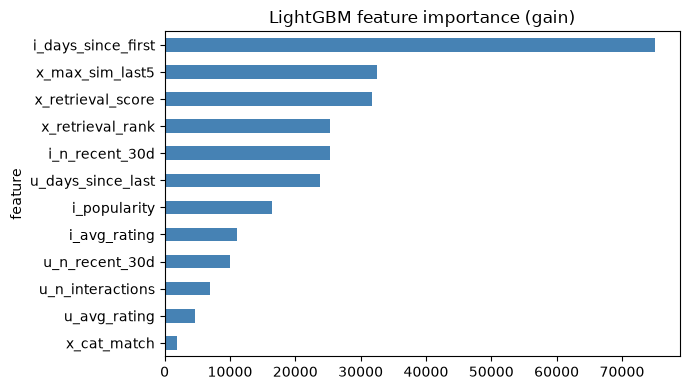

In [8]:
imp = pd.DataFrame({
    'feature': FEATURES,
    'gain':  booster.feature_importance('gain'),
    'split': booster.feature_importance('split'),
}).sort_values('gain', ascending=False)
display(imp.round(1))

ax = imp.set_index('feature')['gain'].plot(kind='barh', figsize=(7, 4), color='steelblue')
ax.invert_yaxis(); ax.set_title('LightGBM feature importance (gain)')
import matplotlib.pyplot as plt
plt.tight_layout(); plt.show()

**Interpretation.** I expected `x_retrieval_score` and `i_popularity` to lead. Wrong: `i_days_since_first` dominates (gain ~75k), then `x_max_sim_last5` and `x_retrieval_score` (~32k), with popularity only 7th. `x_cat_match` is near-zero and the obvious cut. So the ranker leans on item age, similarity to recent reads, and the retriever's own score more than raw popularity.

## 6. Test evaluation - the ablation that justifies the second stage

Retrieval-only top-10 vs re-ranked top-10, on identical candidates. Test groups are **not** filtered by label (that would bias metrics up) - we evaluate exactly like notebooks 02-04.

In [9]:
def evaluate_ranked(cand_dict, truth, rerank):
    recs = {}
    if rerank:
        Xt, _, grps = build_matrix(cand_dict, truth={})   # truth={} -> no group dropping, labels unused
        preds = booster.predict(Xt, num_iteration=booster.best_iteration)
        b = np.concatenate([[0], np.cumsum(grps)])
        for gi, (u, (items, _)) in enumerate(cand_dict.items()):
            order = np.argsort(-preds[b[gi]:b[gi+1]])
            recs[u] = [int(items[o]) for o in order]
    else:
        recs = {u: [int(i) for i in items] for u, (items, _) in cand_dict.items()}
    return recs

def recall_at_k(recs, truth, k):
    s = [len(set(recs.get(u, [])[:k]) & rel) / len(rel) for u, rel in truth.items() if rel]
    return float(np.mean(s)) if s else 0.0

def ndcg_at_k(recs, truth, k):
    out = []
    for u, rel in truth.items():
        top = recs.get(u, [])[:k]
        dcg = sum(1.0 / np.log2(i + 2) for i, it in enumerate(top) if it in rel)
        idcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(rel), k)))
        out.append(dcg / idcg if idcg > 0 else 0.0)
    return float(np.mean(out))

def catalog_coverage(recs, n_items, k):
    seen = set()
    for r in recs.values():
        seen.update(r[:k])
    return len(seen) / n_items

test_users = [u for u in truth_test if u in user_seqs]
# Feature assembly is ~100 rows/user in Python; cap eval users for tractability.
# 100K users gives metric estimates stable to ~3 decimals (documented design decision).
TEST_USER_SAMPLE = 10_000 if SMOKE else 100_000
if len(test_users) > TEST_USER_SAMPLE:
    test_users = list(rng.choice(test_users, size=TEST_USER_SAMPLE, replace=False))
    truth_test = {u: truth_test[u] for u in test_users}
cands_test = retrieve_batch(test_users)

recs_retr = evaluate_ranked(cands_test, truth_test, rerank=False)
recs_rank = evaluate_ranked(cands_test, truth_test, rerank=True)

ablation = pd.DataFrame([
    {'Pipeline': 'Two-tower (retrieval only)',
     'NDCG@10': ndcg_at_k(recs_retr, truth_test, 10),
     'Recall@20': recall_at_k(recs_retr, truth_test, 20),
     'Coverage@10': catalog_coverage(recs_retr, N_ITEMS, 10)},
    {'Pipeline': 'Two-tower + LightGBM',
     'NDCG@10': ndcg_at_k(recs_rank, truth_test, 10),
     'Recall@20': recall_at_k(recs_rank, truth_test, 20),
     'Coverage@10': catalog_coverage(recs_rank, N_ITEMS, 10)},
]).set_index('Pipeline')
display(ablation.round(4))
ablation.to_json(os.path.join(DATA_DIR, 'ablation.json'), orient='index', indent=2)

,NDCG@10,Recall@20,Coverage@10
Pipeline,,,
Two-tower (retrieval only),0.0215,0.0572,0.2996
Two-tower + LightGBM,0.0278,0.0667,0.2885


In [10]:
# Add the full-pipeline row to the shared results table
row = {'Model': 'Two-tower + LightGBM',
       'Recall@20': recall_at_k(recs_rank, truth_test, 20),
       'Recall@50': recall_at_k(recs_rank, truth_test, 50),
       'NDCG@10':   ndcg_at_k(recs_rank, truth_test, 10),
       'Coverage@10': catalog_coverage(recs_rank, N_ITEMS, 10)}
with open(os.path.join(DATA_DIR, 'baseline_results.json')) as f:
    rows = json.load(f)
rows = [r for r in rows if r['Model'] != 'Two-tower + LightGBM'] + [row]
with open(os.path.join(DATA_DIR, 'baseline_results.json'), 'w') as f:
    json.dump(rows, f, indent=2)
pd.DataFrame(rows).set_index('Model').round(4)

,Recall@20,Recall@50,NDCG@10,Coverage@10
Model,,,,
Random,0.0001,0.0004,0.0000,0.9415
Popularity,0.0141,0.0242,0.0053,0.0002
MF-BPR,0.0246,0.0461,0.0092,0.2211
Two-tower,0.0572,0.0967,0.0215,0.2996
Two-tower + LightGBM,0.0667,0.1072,0.0278,0.2885


**Interpretation.** The ranker only reorders a fixed candidate set, so its gain lands in NDCG@10 (0.0215 to 0.0278, +29%); Recall@20 rises less (0.0572 to 0.0667) and coverage dips a little (0.30 to 0.29) as the popularity features pull toward the head.

## 7. Export artifacts for the API

In [11]:
ART_R = os.path.join(DATA_DIR, 'artifacts_ranker')
os.makedirs(ART_R, exist_ok=True)
booster.save_model(os.path.join(ART_R, 'lgbm_ranker.txt'), num_iteration=booster.best_iteration)
user_feat.reset_index().to_parquet(os.path.join(ART_R, 'user_features.parquet'), index=False)
item_feat.reset_index(names='item_idx').to_parquet(os.path.join(ART_R, 'item_features.parquet'), index=False)
with open(os.path.join(ART_R, 'feature_config.json'), 'w') as f:
    json.dump({'features': FEATURES, 't_ref': float(T_REF)}, f, indent=2)
print('Saved ranker + feature tables to', ART_R)

Saved ranker + feature tables to ./data/artifacts_ranker


## 8. Cold-start analysis

Performance by user activity level (interactions in the train period). "cold" = 5-10 interactions: thin histories for the user tower, sparse features for the ranker.

In [12]:
buckets = {'cold (5-10)': (5, 10), 'medium (11-50)': (11, 50), 'heavy (>50)': (51, 10**9)}
act = {u: len(seen_train.get(u, ())) for u in truth_test}
rows = []
for name, (lo, hi) in buckets.items():
    us = [u for u in truth_test if lo <= act[u] <= hi]
    t = {u: truth_test[u] for u in us}
    rows.append({'Group': name, '#Users': len(us),
                 'Recall@20 retrieval': recall_at_k(recs_retr, t, 20),
                 'Recall@20 +ranker':   recall_at_k(recs_rank, t, 20),
                 'NDCG@10 +ranker':     ndcg_at_k(recs_rank, t, 10)})
coldstart = pd.DataFrame(rows).set_index('Group')
display(coldstart.round(4))
coldstart.to_json(os.path.join(DATA_DIR, 'coldstart.json'), orient='index', indent=2)

,#Users,Recall@20 retrieval,Recall@20 +ranker,NDCG@10 +ranker
Group,,,,
cold (5-10),9272,0.0653,0.0775,0.0299
medium (11-50),10796,0.0632,0.0711,0.0311
heavy (>50),5116,0.0364,0.0402,0.0187
